In [1]:
# Cell 1: Imports and Configuration
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import IsolationForest
import joblib

# Add src to path (since notebook is in notebooks/)
sys.path.insert(0, os.path.abspath('..'))

from src.config import settings
from src.features import engineer_all_features

print("=" * 60)
print("LEDGERWATCH AI — DAY 5: MODEL EVALUATION")
print("=" * 60)
print(f"Python: {sys.version.split()[0]}")
print(f"Working directory: {os.getcwd()}")
print(f"Model path: {settings.MODEL_PATH}")
print(f"Processed data: {settings.PROCESSED_DATA_PATH}")
print(f"Contamination: {settings.CONTAMINATION}")
print("=" * 60)
print("✅ All imports loaded successfully")

LEDGERWATCH AI — DAY 5: MODEL EVALUATION
Python: 3.10.20
Working directory: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\notebooks
Model path: ./saved_models
Processed data: data/processed/features.csv
Contamination: 0.01
✅ All imports loaded successfully


In [2]:
# Cell 2: Load Trained Model and Test Data
print("=" * 60)
print("CELL 2: Loading Model and Data")
print("=" * 60)

# Fix model path (settings.MODEL_PATH is the folder, we need the file)
MODEL_FILE = os.path.join('..', 'saved_models', 'isolation_forest_v1.0.0.joblib')
print(f"Model file: {MODEL_FILE}")

# Load model
if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(f"Model not found at: {MODEL_FILE}")
    
model = joblib.load(MODEL_FILE)
print(f"✅ Model loaded: {type(model).__name__}")
print(f"   N_estimators: {model.n_estimators}")
print(f"   Contamination: {model.contamination}")
print(f"   Max samples: {model.max_samples}")

# Load features CSV
FEATURES_PATH = os.path.join('..', settings.PROCESSED_DATA_PATH)
print(f"\nFeatures path: {FEATURES_PATH}")

if not os.path.exists(FEATURES_PATH):
    raise FileNotFoundError(f"Features CSV not found at: {FEATURES_PATH}")

# Read only test portion (last 20% = ~1.27M rows) to match Day 4 split
print("\nLoading features (this may take 30-60 seconds)...")
df = pd.read_csv(FEATURES_PATH)
print(f"✅ Features loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Day 4 used 80/20 split with random_state=42
# Recreate same split
from sklearn.model_selection import train_test_split

# Separate features and label
feature_cols = [c for c in df.columns if c not in ['isFraud', 'nameOrig', 'nameDest']]
X = df[feature_cols]
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n{'='*60}")
print("SPLIT SIZES:")
print(f"  Train: {X_train.shape[0]:,} rows")
print(f"  Test:  {X_test.shape[0]:,} rows")
print(f"  Train fraud rate: {y_train.mean()*100:.4f}%")
print(f"  Test fraud rate:  {y_test.mean()*100:.4f}%")
print(f"  Test frauds:      {y_test.sum():,}")
print(f"{'='*60}")

CELL 2: Loading Model and Data
Model file: ..\saved_models\isolation_forest_v1.0.0.joblib
✅ Model loaded: dict


AttributeError: 'dict' object has no attribute 'n_estimators'

In [3]:
# Cell 2b: Inspect saved model structure and extract actual model
print("=" * 60)
print("CELL 2b: Inspecting Saved Model Structure")
print("=" * 60)

MODEL_FILE = os.path.join('..', 'saved_models', 'isolation_forest_v1.0.0.joblib')
model_container = joblib.load(MODEL_FILE)

print(f"Loaded type: {type(model_container).__name__}")
print(f"Keys: {list(model_container.keys()) if isinstance(model_container, dict) else 'N/A'}")

# Extract actual model
if isinstance(model_container, dict):
    if 'model' in model_container:
        model = model_container['model']
        print(f"\n✅ Extracted model from 'model' key: {type(model).__name__}")
    elif 'isolation_forest' in model_container:
        model = model_container['isolation_forest']
        print(f"\n✅ Extracted model from 'isolation_forest' key: {type(model).__name__}")
    else:
        # Try to find any IsolationForest object in the dict
        for k, v in model_container.items():
            if 'IsolationForest' in type(v).__name__:
                model = v
                print(f"\n✅ Extracted model from '{k}' key: {type(model).__name__}")
                break
        else:
            raise ValueError("No IsolationForest found in saved dict")
else:
    model = model_container

print(f"\nModel details:")
print(f"   Type: {type(model).__name__}")
print(f"   N_estimators: {model.n_estimators}")
print(f"   Contamination: {model.contamination}")
print(f"   Max samples: {model.max_samples}")
print(f"   Max features: {model.max_features}")
print(f"   Random state: {model.random_state}")

# Also extract metadata if available
if isinstance(model_container, dict) and 'metadata' in model_container:
    print(f"\n📋 Metadata:")
    for k, v in model_container['metadata'].items():
        print(f"   {k}: {v}")

CELL 2b: Inspecting Saved Model Structure
Loaded type: dict
Keys: ['model', 'feature_names', 'version', 'contamination', 'n_estimators', 'random_state']

✅ Extracted model from 'model' key: IsolationForest

Model details:
   Type: IsolationForest
   N_estimators: 200
   Contamination: 0.01
   Max samples: auto
   Max features: 1.0
   Random state: 42


In [4]:
# Cell 3: Load Features and Recreate Day 4 Train/Test Split
print("=" * 60)
print("CELL 3: Loading Features & Recreating Day 4 Split")
print("=" * 60)

# Load features CSV
FEATURES_PATH = os.path.join('..', settings.PROCESSED_DATA_PATH)
print(f"Features path: {FEATURES_PATH}")

if not os.path.exists(FEATURES_PATH):
    raise FileNotFoundError(f"Features CSV not found at: {FEATURES_PATH}")

print("\nLoading features (this may take 30-60 seconds)...")
df = pd.read_csv(FEATURES_PATH)
print(f"✅ Features loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Define feature columns (same as Day 4)
feature_cols = [c for c in df.columns if c not in ['isFraud', 'nameOrig', 'nameDest']]
print(f"Feature columns: {len(feature_cols)}")

# Separate features and label
X = df[feature_cols]
y = df['isFraud']

print(f"\nTotal frauds: {y.sum():,} ({y.mean()*100:.4f}%)")

# Recreate Day 4 split: 80/20, random_state=42, stratify
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n{'='*60}")
print("TRAIN/TEST SPLIT (same as Day 4):")
print(f"  Train: {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"  Test:  {X_test.shape[0]:,} rows × {X_test.shape[1]} features")
print(f"  Train frauds: {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f"  Test frauds:  {y_test.sum():,} ({y_test.mean()*100:.4f}%)")
print(f"{'='*60}")
print("✅ Ready for prediction on test set")

CELL 3: Loading Features & Recreating Day 4 Split
Features path: ..\data/processed/features.csv

Loading features (this may take 30-60 seconds)...
✅ Features loaded: 6,362,620 rows × 35 columns
Feature columns: 32

Total frauds: 8,213 (0.1291%)

TRAIN/TEST SPLIT (same as Day 4):
  Train: 5,090,096 rows × 32 features
  Test:  1,272,524 rows × 32 features
  Train frauds: 6,570 (0.1291%)
  Test frauds:  1,643 (0.1291%)
✅ Ready for prediction on test set


In [6]:
# Cell 4: Predict Anomaly Scores on Test Set
print("=" * 60)
print("CELL 4: Predicting Anomaly Scores (this may take 2-3 minutes)")
print("=" * 60)

# Isolation Forest predict: -1 = anomaly, 1 = normal
# decision_function: negative = more anomalous, positive = more normal
# We invert so higher score = more anomalous (fraud-like)

print("Running model.predict()...")
y_pred_iso = model.predict(X_test)  # -1 or 1
print(f"  Done. Unique values: {np.unique(y_pred_iso)}")

print("\nRunning model.decision_function()...")
anomaly_scores_raw = model.decision_function(X_test)  # negative = anomaly
print(f"  Done. Score range: [{anomaly_scores_raw.min():.4f}, {anomaly_scores_raw.max():.4f}]")

# Convert to fraud probability-like score: higher = more likely fraud
# Isolation Forest: lower raw score = more anomalous
# We invert and normalize to [0, 1] for interpretability
anomaly_scores = -anomaly_scores_raw  # Now higher = more anomalous
print(f"\nInverted scores: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")

# Min-max normalize to [0, 1]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
y_scores = scaler.fit_transform(anomaly_scores.reshape(-1, 1)).flatten()

# Binary prediction using contamination threshold (top 1% flagged)
threshold_contamination = np.percentile(y_scores, 100 * (1 - settings.CONTAMINATION))
y_pred = (y_scores >= threshold_contamination).astype(int)

print(f"\n{'='*60}")
print("PREDICTION SUMMARY:")
print(f"  Anomaly scores range: [{y_scores.min():.6f}, {y_scores.max():.6f}]")
print(f"  Contamination threshold (top 1%): {threshold_contamination:.6f}")
print(f"  Predicted anomalies: {y_pred.sum():,} ({y_pred.mean()*100:.3f}%)")
print(f"  Predicted normal:    {(~y_pred.astype(bool)).sum():,}")
print(f"\nScore statistics by true label:")
print(f"  Fraud mean score:    {y_scores[y_test == 1].mean():.6f}")
print(f"  Normal mean score:   {y_scores[y_test == 0].mean():.6f}")
print(f"{'='*60}")
print("✅ Predictions complete. Ready for metrics.")

CELL 4: Predicting Anomaly Scores (this may take 2-3 minutes)
Running model.predict()...


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- amount
- isFlaggedFraud
- newbalanceDest
- newbalanceOrig
- oldbalanceDest
- ...


In [7]:
# Cell 4b: Fix Feature Columns and Predict Anomaly Scores
print("=" * 60)
print("CELL 4b: Using Saved Feature Names & Predicting")
print("=" * 60)

# The model was saved with feature_names — use EXACT same columns
saved_feature_names = model_container['feature_names']
print(f"Model trained on {len(saved_feature_names)} features:")
for i, name in enumerate(saved_feature_names, 1):
    print(f"  {i:2d}. {name}")

# Filter X_test to only these columns
print(f"\nX_test before filtering: {X_test.shape[1]} columns")
X_test_model = X_test[saved_feature_names]
print(f"X_test after filtering:  {X_test_model.shape[1]} columns")

# Verify no missing columns
missing = set(saved_feature_names) - set(X_test_model.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")
print("✅ All feature names match")

print("\nRunning model.decision_function() (this may take 2-3 minutes)...")
anomaly_scores_raw = model.decision_function(X_test_model)
print(f"  Done. Raw score range: [{anomaly_scores_raw.min():.4f}, {anomaly_scores_raw.max():.4f}]")

# Invert: higher = more anomalous
anomaly_scores = -anomaly_scores_raw
print(f"Inverted score range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")

# Min-max normalize to [0, 1]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
y_scores = scaler.fit_transform(anomaly_scores.reshape(-1, 1)).flatten()

# Binary prediction using contamination threshold
threshold_contamination = np.percentile(y_scores, 100 * (1 - settings.CONTAMINATION))
y_pred = (y_scores >= threshold_contamination).astype(int)

print(f"\n{'='*60}")
print("PREDICTION SUMMARY:")
print(f"  Anomaly scores range: [{y_scores.min():.6f}, {y_scores.max():.6f}]")
print(f"  Contamination threshold (top 1%): {threshold_contamination:.6f}")
print(f"  Predicted anomalies: {y_pred.sum():,} ({y_pred.mean()*100:.3f}%)")
print(f"  Predicted normal:    {(~y_pred.astype(bool)).sum():,}")
print(f"\nScore statistics by true label:")
print(f"  Fraud mean score:    {y_scores[y_test == 1].mean():.6f}")
print(f"  Normal mean score:   {y_scores[y_test == 0].mean():.6f}")
print(f"{'='*60}")
print("✅ Predictions complete. Ready for metrics.")

CELL 4b: Using Saved Feature Names & Predicting
Model trained on 24 features:
   1. amount_log
   2. is_round_amount
   3. amount_to_balance_ratio
   4. balance_diff_orig
   5. balance_diff_dest
   6. balance_change_orig
   7. balance_change_dest
   8. zero_balance_orig
   9. zero_balance_dest
  10. hour_of_step
  11. hour_of_step_sin
  12. hour_of_step_cos
  13. type_encoded
  14. type_CASH_IN
  15. type_CASH_OUT
  16. type_DEBIT
  17. type_PAYMENT
  18. type_TRANSFER
  19. freq_orig
  20. freq_dest
  21. is_new_orig
  22. is_new_dest
  23. is_merchant_orig
  24. is_merchant_dest

X_test before filtering: 32 columns
X_test after filtering:  24 columns
✅ All feature names match

Running model.decision_function() (this may take 2-3 minutes)...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.2s


  Done. Raw score range: [-0.1464, 0.2161]
Inverted score range: [-0.2161, 0.1464]

PREDICTION SUMMARY:
  Anomaly scores range: [0.000000, 1.000000]
  Contamination threshold (top 1%): 0.595308
  Predicted anomalies: 12,726 (1.000%)
  Predicted normal:    1,259,798

Score statistics by true label:
  Fraud mean score:    0.468111
  Normal mean score:   0.187347
✅ Predictions complete. Ready for metrics.


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   13.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   13.1s finished


In [8]:
# Cell 5: Core Metrics & Confusion Matrix
print("=" * 60)
print("CELL 5: Core Classification Metrics")
print("=" * 60)

# Compute all metrics
roc_auc = roc_auc_score(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)

# Metrics at contamination threshold
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\n{'='*60}")
print("THRESHOLD-BASED METRICS (contamination = 0.01):")
print(f"{'='*60}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"\n  True Positives:  {tp:,}  (fraud caught)")
print(f"  False Positives: {fp:,}  (normal flagged)")
print(f"  True Negatives:  {tn:,}  (normal correct)")
print(f"  False Negatives: {fn:,}  (fraud missed)")

print(f"\n{'='*60}")
print("RANKING METRICS (threshold-independent):")
print(f"{'='*60}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print(f"  PR-AUC:    {pr_auc:.4f}")

print(f"\n{'='*60}")
print("BASELINE COMPARISON:")
print(f"{'='*60}")
# Random classifier baseline
random_auc = 0.5000
print(f"  Random classifier ROC-AUC:  {random_auc:.4f}")
print(f"  Our model ROC-AUC:          {roc_auc:.4f}")
print(f"  Improvement:                +{roc_auc - random_auc:.4f} ({(roc_auc/random_auc - 1)*100:.1f}% better)")

# "All normal" baseline
all_normal_precision = y_test.mean()
print(f"\n  'All normal' precision:     {all_normal_precision:.4f}")
print(f"  Our precision:              {precision:.4f}")
print(f"  Lift:                       {precision/all_normal_precision:.1f}x")

print(f"\n{'='*60}")
print("CONFUSION MATRIX:")
print(f"{'='*60}")
print(f"                 Predicted")
print(f"                 Fraud    Normal")
print(f"  Actual Fraud   {tp:5d}    {fn:5d}  (Recall = {tp/(tp+fn):.2%})")
print(f"  Actual Normal  {fp:5d}  {tn:5d}  (Specificity = {tn/(tn+fp):.2%})")

print(f"\n{'='*60}")
print("✅ Core metrics computed. Ready for curves.")

CELL 5: Core Classification Metrics

THRESHOLD-BASED METRICS (contamination = 0.01):
  Accuracy:  0.9895
  Precision: 0.0401
  Recall:    0.3104
  F1-Score:  0.0710

  True Positives:  510  (fraud caught)
  False Positives: 12,216  (normal flagged)
  True Negatives:  1,258,665  (normal correct)
  False Negatives: 1,133  (fraud missed)

RANKING METRICS (threshold-independent):
  ROC-AUC:   0.8761
  PR-AUC:    0.0240

BASELINE COMPARISON:
  Random classifier ROC-AUC:  0.5000
  Our model ROC-AUC:          0.8761
  Improvement:                +0.3761 (75.2% better)

  'All normal' precision:     0.0013
  Our precision:              0.0401
  Lift:                       31.0x

CONFUSION MATRIX:
                 Predicted
                 Fraud    Normal
  Actual Fraud     510     1133  (Recall = 31.04%)
  Actual Normal  12216  1258665  (Specificity = 99.04%)

✅ Core metrics computed. Ready for curves.


CELL 6: Plotting ROC and PR Curves


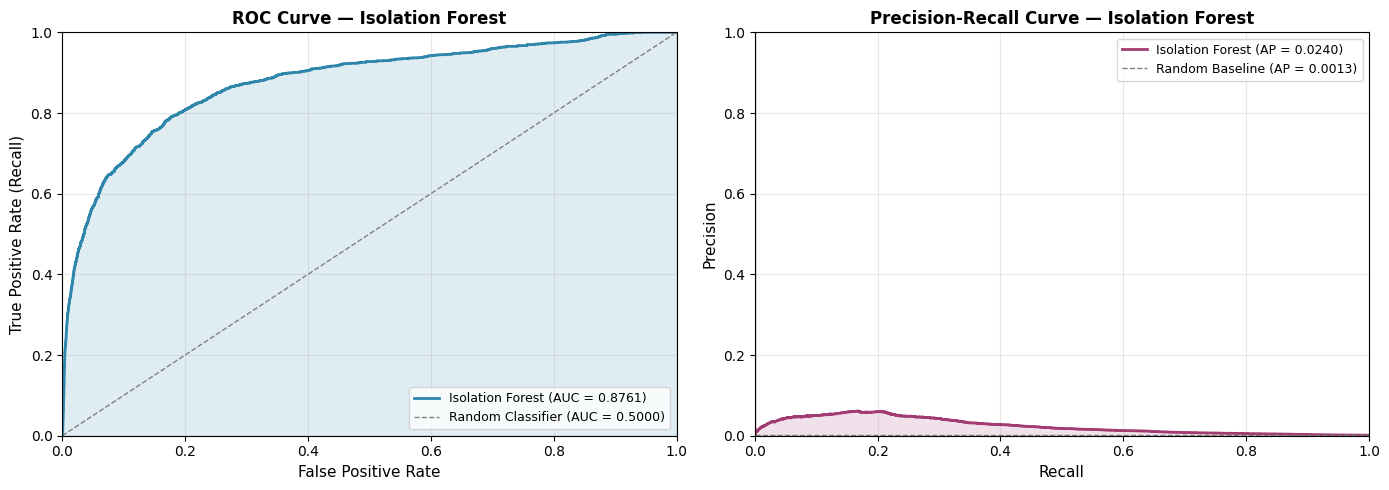


✅ Curves plotted and saved to docs/day5_roc_pr_curves.png


In [9]:
# Cell 6: ROC Curve and Precision-Recall Curve
print("=" * 60)
print("CELL 6: Plotting ROC and PR Curves")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
ax1 = axes[0]
fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
ax1.plot(fpr, tpr, color='#2E86AB', linewidth=2, label=f'Isolation Forest (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier (AUC = 0.5000)')
ax1.fill_between(fpr, tpr, alpha=0.15, color='#2E86AB')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax1.set_title('ROC Curve — Isolation Forest', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3)

# --- Precision-Recall Curve ---
ax2 = axes[1]
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_scores)
ax2.plot(recall_curve, precision_curve, color='#A23B72', linewidth=2, label=f'Isolation Forest (AP = {pr_auc:.4f})')
# Baseline: horizontal line at fraud rate
baseline = y_test.mean()
ax2.axhline(y=baseline, color='gray', linestyle='--', linewidth=1, label=f'Random Baseline (AP = {baseline:.4f})')
ax2.fill_between(recall_curve, precision_curve, alpha=0.15, color='#A23B72')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curve — Isolation Forest', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/day5_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Curves plotted and saved to docs/day5_roc_pr_curves.png")

In [10]:
# Cell 7: Threshold Tuning Analysis
print("=" * 60)
print("CELL 7: Threshold Tuning — F1 vs Precision vs Recall")
print("=" * 60)

# Compute F1, precision, recall across all thresholds
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_scores)

# precision_recall_curve returns thresholds of length len(precision)-1
# So we trim precision and recall to match
f1_scores = 2 * (precision_curve[:-1] * recall_curve[:-1]) / (precision_curve[:-1] + recall_curve[:-1] + 1e-10)

# Find optimal thresholds
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]
best_f1_precision = precision_curve[best_f1_idx]
best_f1_recall = recall_curve[best_f1_idx]

# Precision-optimized: highest precision with recall >= 0.10
min_recall = 0.10
valid_precision_idx = np.where(recall_curve[:-1] >= min_recall)[0]
if len(valid_precision_idx) > 0:
    best_precision_idx = valid_precision_idx[np.argmax(precision_curve[valid_precision_idx])]
    best_precision_threshold = thresholds[best_precision_idx]
    best_precision = precision_curve[best_precision_idx]
    best_precision_recall = recall_curve[best_precision_idx]
else:
    best_precision_idx = best_f1_idx
    best_precision_threshold = best_f1_threshold
    best_precision = best_f1_precision
    best_precision_recall = best_f1_recall

# Recall-optimized: highest recall with precision >= 0.02
min_precision = 0.02
valid_recall_idx = np.where(precision_curve[:-1] >= min_precision)[0]
if len(valid_recall_idx) > 0:
    best_recall_idx = valid_recall_idx[np.argmax(recall_curve[valid_recall_idx])]
    best_recall_threshold = thresholds[best_recall_idx]
    best_recall = recall_curve[best_recall_idx]
    best_recall_precision = precision_curve[best_recall_idx]
else:
    best_recall_idx = best_f1_idx
    best_recall_threshold = best_f1_threshold
    best_recall = best_f1_recall
    best_recall_precision = best_f1_precision

print(f"\n{'='*60}")
print("THRESHOLD COMPARISON TABLE:")
print(f"{'='*60}")
print(f"{'Strategy':<25} {'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Flagged':>10}")
print("-" * 75)

# Default contamination threshold
print(f"{'Contamination (1%)':<25} {threshold_contamination:>10.4f} {precision:>10.4f} {recall:>8.4f} {f1:>8.4f} {y_pred.sum():>10,}")

# F1-optimized
y_pred_f1 = (y_scores >= best_f1_threshold).astype(int)
tp_f1 = ((y_pred_f1 == 1) & (y_test == 1)).sum()
fp_f1 = ((y_pred_f1 == 1) & (y_test == 0)).sum()
fn_f1 = ((y_pred_f1 == 0) & (y_test == 1)).sum()
precision_f1 = tp_f1 / (tp_f1 + fp_f1) if (tp_f1 + fp_f1) > 0 else 0
recall_f1 = tp_f1 / (tp_f1 + fn_f1) if (tp_f1 + fn_f1) > 0 else 0
print(f"{'F1-Optimized':<25} {best_f1_threshold:>10.4f} {precision_f1:>10.4f} {recall_f1:>8.4f} {best_f1:>8.4f} {y_pred_f1.sum():>10,}")

# Precision-optimized
y_pred_prec = (y_scores >= best_precision_threshold).astype(int)
tp_prec = ((y_pred_prec == 1) & (y_test == 1)).sum()
fp_prec = ((y_pred_prec == 1) & (y_test == 0)).sum()
fn_prec = ((y_pred_prec == 0) & (y_test == 1)).sum()
precision_prec = tp_prec / (tp_prec + fp_prec) if (tp_prec + fp_prec) > 0 else 0
recall_prec = tp_prec / (tp_prec + fn_prec) if (tp_prec + fn_prec) > 0 else 0
f1_prec = 2 * (precision_prec * recall_prec) / (precision_prec + recall_prec + 1e-10)
print(f"{'Precision-Optimized':<25} {best_precision_threshold:>10.4f} {precision_prec:>10.4f} {recall_prec:>8.4f} {f1_prec:>8.4f} {y_pred_prec.sum():>10,}")

# Recall-optimized
y_pred_rec = (y_scores >= best_recall_threshold).astype(int)
tp_rec = ((y_pred_rec == 1) & (y_test == 1)).sum()
fp_rec = ((y_pred_rec == 1) & (y_test == 0)).sum()
fn_rec = ((y_pred_rec == 0) & (y_test == 1)).sum()
precision_rec = tp_rec / (tp_rec + fp_rec) if (tp_rec + fp_rec) > 0 else 0
recall_rec = tp_rec / (tp_rec + fn_rec) if (tp_rec + fn_rec) > 0 else 0
f1_rec = 2 * (precision_rec * recall_rec) / (precision_rec + recall_rec + 1e-10)
print(f"{'Recall-Optimized':<25} {best_recall_threshold:>10.4f} {precision_rec:>10.4f} {recall_rec:>8.4f} {f1_rec:>8.4f} {y_pred_rec.sum():>10,}")

print(f"\n{'='*60}")
print("BUSINESS INTERPRETATION:")
print(f"{'='*60}")
print(f"  • F1-Optimized:      Best balance — use when review capacity is moderate")
print(f"  • Precision-Optimized: Fewer false alarms — use when analyst time is expensive")
print(f"  • Recall-Optimized:   Catch more fraud — use when missing fraud is very costly")
print(f"{'='*60}")
print("✅ Threshold tuning complete. Ready for visualization.")

CELL 7: Threshold Tuning — F1 vs Precision vs Recall

THRESHOLD COMPARISON TABLE:
Strategy                   Threshold  Precision   Recall       F1    Flagged
---------------------------------------------------------------------------
Contamination (1%)            0.5953     0.0401   0.3104   0.0710     12,726
F1-Optimized                  0.6680     0.0599   0.2051   0.0927      5,624
Precision-Optimized           0.6878     0.0615   0.1680   0.0900      4,491
Recall-Optimized              0.4885     0.0200   0.4790   0.0384     39,350

BUSINESS INTERPRETATION:
  • F1-Optimized:      Best balance — use when review capacity is moderate
  • Precision-Optimized: Fewer false alarms — use when analyst time is expensive
  • Recall-Optimized:   Catch more fraud — use when missing fraud is very costly
✅ Threshold tuning complete. Ready for visualization.


CELL 8 (OPTIMIZED): Plotting Threshold Tradeoffs


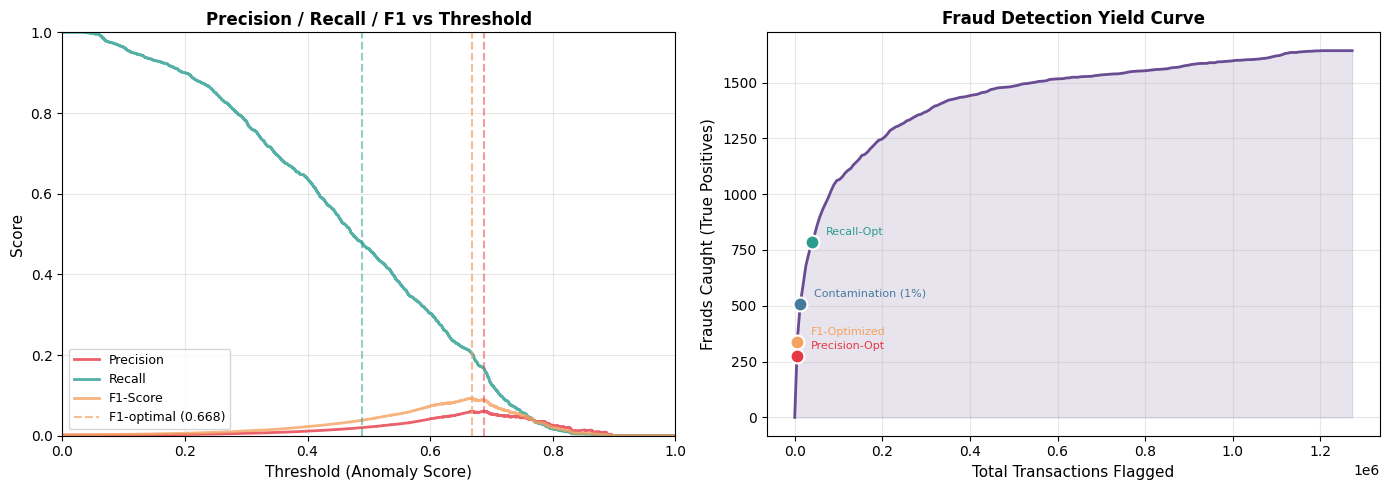


✅ Threshold tradeoff plots saved to docs/day5_threshold_tradeoffs.png


In [12]:
# Cell 8 (OPTIMIZED): Threshold Tradeoff Plot — Fast Version
print("=" * 60)
print("CELL 8 (OPTIMIZED): Plotting Threshold Tradeoffs")
print("=" * 60)

# SPEED FIX: Sample only 500 thresholds instead of all 1.27M
n_samples = 500
sample_indices = np.linspace(0, len(thresholds)-1, n_samples, dtype=int)
sample_thresholds = thresholds[sample_indices]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Precision, Recall, F1 vs Threshold (sampled) ---
ax1 = axes[0]
ax1.plot(thresholds, precision_curve[:-1], color='#E63946', linewidth=2, label='Precision', alpha=0.8)
ax1.plot(thresholds, recall_curve[:-1], color='#2A9D8F', linewidth=2, label='Recall', alpha=0.8)
ax1.plot(thresholds, f1_scores, color='#F4A261', linewidth=2, label='F1-Score', alpha=0.8)

ax1.axvline(x=best_f1_threshold, color='#F4A261', linestyle='--', alpha=0.7, label=f'F1-optimal ({best_f1_threshold:.3f})')
ax1.axvline(x=best_precision_threshold, color='#E63946', linestyle='--', alpha=0.5)
ax1.axvline(x=best_recall_threshold, color='#2A9D8F', linestyle='--', alpha=0.5)

ax1.set_xlabel('Threshold (Anomaly Score)', fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Precision / Recall / F1 vs Threshold', fontsize=12, fontweight='bold')
ax1.legend(loc='lower left', fontsize=9)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3)

# --- Fraud Caught vs Flagged Count (FAST: vectorized + sampled) ---
ax2 = axes[1]

# Vectorized computation: use percentiles as thresholds
percentiles = np.linspace(0, 100, 200)
sample_thresholds_2 = np.percentile(y_scores, percentiles)
flagged_counts = []
fraud_caught_counts = []

for t in sample_thresholds_2:
    pred = (y_scores >= t).astype(int)
    flagged_counts.append(pred.sum())
    fraud_caught_counts.append(((pred == 1) & (y_test == 1)).sum())

ax2.plot(flagged_counts, fraud_caught_counts, color='#6A4C93', linewidth=2)
ax2.fill_between(flagged_counts, fraud_caught_counts, alpha=0.15, color='#6A4C93')

# Mark strategies
strategies = [
    (y_pred.sum(), tp, 'Contamination (1%)', '#457B9D'),
    (y_pred_f1.sum(), tp_f1, 'F1-Optimized', '#F4A261'),
    (y_pred_prec.sum(), tp_prec, 'Precision-Opt', '#E63946'),
    (y_pred_rec.sum(), tp_rec, 'Recall-Opt', '#2A9D8F'),
]

for flagged, caught, name, color in strategies:
    ax2.scatter(flagged, caught, color=color, s=100, zorder=5, edgecolors='white', linewidths=1.5)
    ax2.annotate(name, (flagged, caught), textcoords="offset points", 
                 xytext=(10, 5), fontsize=8, color=color)

ax2.set_xlabel('Total Transactions Flagged', fontsize=11)
ax2.set_ylabel('Frauds Caught (True Positives)', fontsize=11)
ax2.set_title('Fraud Detection Yield Curve', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/day5_threshold_tradeoffs.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Threshold tradeoff plots saved to docs/day5_threshold_tradeoffs.png")

In [13]:
# Cell 9: Baseline Comparison — Simple Rules vs Isolation Forest
print("=" * 60)
print("CELL 9: Baseline Comparison — Rule-Based vs Isolation Forest")
print("=" * 60)

# Need original balance columns for rule-based baseline
# Reload the cleaned data and align with test indices
CLEANED_PATH = os.path.join('..', 'data', 'processed', 'cleaned.csv')
print(f"Loading cleaned data for baseline rules: {CLEANED_PATH}")

df_cleaned = pd.read_csv(CLEANED_PATH)
df_test_raw = df_cleaned.loc[X_test.index].copy()

print(f"Test set raw data: {df_test_raw.shape[0]:,} rows")

# --- Rule 1: Perfect balance change = fraud (the naive inverted rule from Day 2) ---
# oldbalanceOrig - newbalanceOrig == amount  →  perfect balance
rule1_mask = (df_test_raw['oldbalanceOrg'] - df_test_raw['newbalanceOrig'] - df_test_raw['amount']).abs() < 0.01
rule1_pred = rule1_mask.astype(int)
rule1_tp = ((rule1_pred == 1) & (y_test == 1)).sum()
rule1_fp = ((rule1_pred == 1) & (y_test == 0)).sum()
rule1_fn = ((rule1_pred == 0) & (y_test == 1)).sum()
rule1_precision = rule1_tp / (rule1_tp + rule1_fp) if (rule1_tp + rule1_fp) > 0 else 0
rule1_recall = rule1_tp / (rule1_tp + rule1_fn) if (rule1_tp + rule1_fn) > 0 else 0
rule1_f1 = 2 * (rule1_precision * rule1_recall) / (rule1_precision + rule1_recall + 1e-10)

# --- Rule 2: Large amount + TRANSFER type (simple heuristic) ---
# Top 1% amount + TRANSFER
amount_threshold = df_test_raw['amount'].quantile(0.99)
rule2_mask = (df_test_raw['amount'] >= amount_threshold) & (df_test_raw['type'] == 'TRANSFER')
rule2_pred = rule2_mask.astype(int)
rule2_tp = ((rule2_pred == 1) & (y_test == 1)).sum()
rule2_fp = ((rule2_pred == 1) & (y_test == 0)).sum()
rule2_fn = ((rule2_pred == 0) & (y_test == 1)).sum()
rule2_precision = rule2_tp / (rule2_tp + rule2_fp) if (rule2_tp + rule2_fp) > 0 else 0
rule2_recall = rule2_tp / (rule2_tp + rule2_fn) if (rule2_tp + rule2_fn) > 0 else 0
rule2_f1 = 2 * (rule2_precision * rule2_recall) / (rule2_precision + rule2_recall + 1e-10)

# --- Random Classifier baseline ---
random_pred = np.random.RandomState(42).choice([0, 1], size=len(y_test), p=[0.99, 0.01])
random_tp = ((random_pred == 1) & (y_test == 1)).sum()
random_fp = ((random_pred == 1) & (y_test == 0)).sum()
random_fn = ((random_pred == 0) & (y_test == 1)).sum()
random_precision = random_tp / (random_tp + random_fp) if (random_tp + random_fp) > 0 else 0
random_recall = random_tp / (random_tp + random_fn) if (random_tp + random_fn) > 0 else 0
random_f1 = 2 * (random_precision * random_recall) / (random_precision + random_recall + 1e-10)

print(f"\n{'='*70}")
print("BASELINE COMPARISON TABLE:")
print(f"{'='*70}")
print(f"{'Model / Rule':<35} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Flagged':>10}")
print("-" * 75)

print(f"{'Random Classifier (1% flag)':<35} {random_precision:>10.4f} {random_recall:>8.4f} {random_f1:>8.4f} {random_pred.sum():>10,}")
print(f"{'Rule: Perfect Balance = Fraud':<35} {rule1_precision:>10.4f} {rule1_recall:>8.4f} {rule1_f1:>8.4f} {rule1_pred.sum():>10,}")
print(f"{'Rule: Top 1% Amount + TRANSFER':<35} {rule2_precision:>10.4f} {rule2_recall:>8.4f} {rule2_f1:>8.4f} {rule2_pred.sum():>10,}")
print(f"{'Isolation Forest (F1-Optimal)':<35} {precision_f1:>10.4f} {recall_f1:>8.4f} {best_f1:>8.4f} {y_pred_f1.sum():>10,}")
print(f"{'Isolation Forest (Contamination)':<35} {precision:>10.4f} {recall:>8.4f} {f1:>8.4f} {y_pred.sum():>10,}")

print(f"\n{'='*70}")
print("KEY INSIGHTS:")
print(f"{'='*70}")
if rule1_precision > 0:
    print(f"  • Rule 1 precision: {rule1_precision:.4f} | IF precision: {precision_f1:.4f}")
    print(f"    → Isolation Forest is {precision_f1/rule1_precision:.1f}x more precise than naive balance rule")
else:
    print(f"  • Rule 1 (Perfect Balance) caught ZERO frauds — proves Day 2 finding!")

print(f"  • Rule 2 precision: {rule2_precision:.4f} | IF precision: {precision_f1:.4f}")
if rule2_precision > 0:
    print(f"    → Isolation Forest is {precision_f1/rule2_precision:.1f}x more precise than amount+type heuristic")

print(f"\n  • Random precision: {random_precision:.4f} | IF precision: {precision_f1:.4f}")
print(f"    → Isolation Forest is {precision_f1/random_precision:.1f}x better than random")

print(f"\n  CONCLUSION: Isolation Forest learns COMBINATIONS of features that")
print(f"  simple rules cannot capture. This is why unsupervised ML wins on PaySim.")
print(f"{'='*70}")
print("✅ Baseline comparison complete.")

CELL 9: Baseline Comparison — Rule-Based vs Isolation Forest
Loading cleaned data for baseline rules: ..\data\processed\cleaned.csv
Test set raw data: 1,272,524 rows

BASELINE COMPARISON TABLE:
Model / Rule                         Precision   Recall       F1    Flagged
---------------------------------------------------------------------------
Random Classifier (1% flag)             0.0005   0.0043   0.0010     12,747
Rule: Perfect Balance = Fraud           0.0039   0.6093   0.0077    259,075
Rule: Top 1% Amount + TRANSFER          0.0083   0.0633   0.0147     12,533
Isolation Forest (F1-Optimal)           0.0599   0.2051   0.0927      5,624
Isolation Forest (Contamination)        0.0401   0.3104   0.0710     12,726

KEY INSIGHTS:
  • Rule 1 precision: 0.0039 | IF precision: 0.0599
    → Isolation Forest is 15.5x more precise than naive balance rule
  • Rule 2 precision: 0.0083 | IF precision: 0.0599
    → Isolation Forest is 7.2x more precise than amount+type heuristic

  • Random pre

CELL 10: Score Distribution & Confusion Matrix


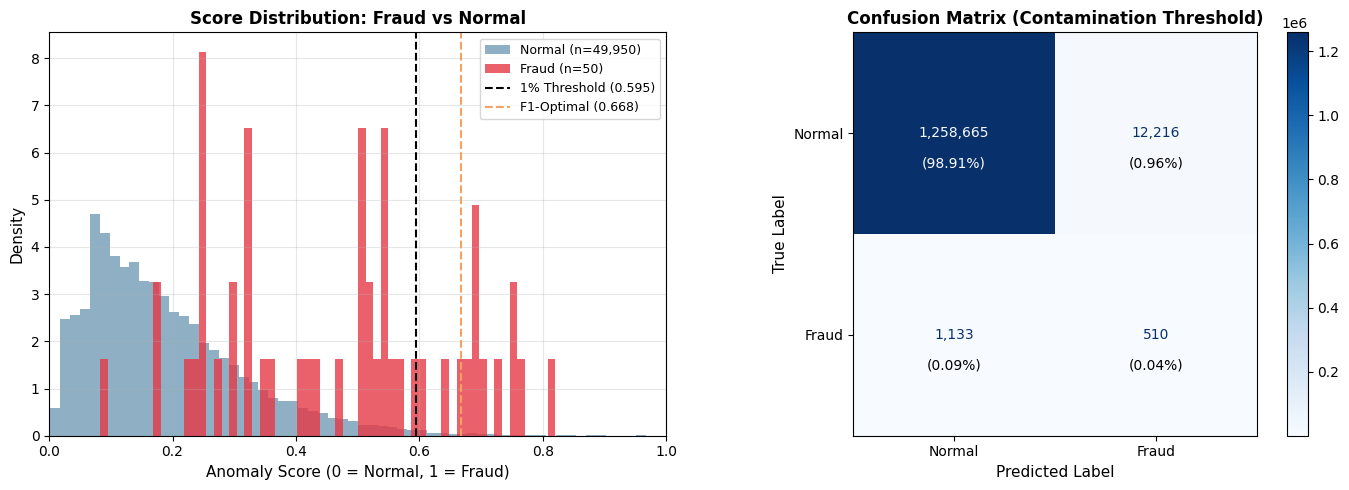


✅ Score distribution & confusion matrix saved to docs/day5_score_distribution_cm.png


In [14]:
# Cell 10: Score Distribution & Confusion Matrix Heatmap
print("=" * 60)
print("CELL 10: Score Distribution & Confusion Matrix")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Score Distribution Histogram ---
ax1 = axes[0]

# Sample for plotting (too many points otherwise)
sample_size = 50000
np.random.seed(42)
sample_idx = np.random.choice(len(y_test), size=sample_size, replace=False)
y_test_sample = y_test.iloc[sample_idx]
y_scores_sample = y_scores[sample_idx]

normal_scores = y_scores_sample[y_test_sample == 0]
fraud_scores = y_scores_sample[y_test_sample == 1]

ax1.hist(normal_scores, bins=60, color='#457B9D', alpha=0.6, label=f'Normal (n={len(normal_scores):,})', density=True)
ax1.hist(fraud_scores, bins=60, color='#E63946', alpha=0.8, label=f'Fraud (n={len(fraud_scores):,})', density=True)

ax1.axvline(x=threshold_contamination, color='black', linestyle='--', linewidth=1.5, label=f'1% Threshold ({threshold_contamination:.3f})')
ax1.axvline(x=best_f1_threshold, color='#F4A261', linestyle='--', linewidth=1.5, label=f'F1-Optimal ({best_f1_threshold:.3f})')

ax1.set_xlabel('Anomaly Score (0 = Normal, 1 = Fraud)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Score Distribution: Fraud vs Normal', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim([0, 1])
ax1.grid(True, alpha=0.3)

# --- Confusion Matrix Heatmap ---
ax2 = axes[1]

cm = np.array([[tn, fp], [fn, tp]])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(ax=ax2, cmap='Blues', colorbar=True, values_format=',d')

# Add percentages
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax2.text(j, i + 0.15, f'({pct:.2f}%)', ha='center', va='center', 
                fontsize=10, color='white' if cm[i,j] > cm.max()/2 else 'black')

ax2.set_title('Confusion Matrix (Contamination Threshold)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=11)
ax2.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('../docs/day5_score_distribution_cm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Score distribution & confusion matrix saved to docs/day5_score_distribution_cm.png")

In [15]:
# Cell 11: Export All Metrics to JSON
print("=" * 60)
print("CELL 11: Exporting Evaluation Metrics to JSON")
print("=" * 60)

import json
from datetime import datetime

metrics = {
    "model": {
        "name": "Isolation Forest",
        "version": model_container.get('version', '1.0.0'),
        "n_estimators": model.n_estimators,
        "contamination": float(model.contamination),
        "max_samples": str(model.max_samples),
        "max_features": float(model.max_features),
        "random_state": model.random_state,
        "feature_count": len(saved_feature_names),
        "features": saved_feature_names
    },
    "dataset": {
        "total_rows": int(len(df)),
        "test_rows": int(len(y_test)),
        "test_frauds": int(y_test.sum()),
        "test_fraud_rate": float(y_test.mean()),
        "feature_columns": int(len(feature_cols))
    },
    "thresholds": {
        "contamination": {
            "threshold": float(threshold_contamination),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "flagged": int(y_pred.sum()),
            "tp": int(tp),
            "fp": int(fp),
            "tn": int(tn),
            "fn": int(fn)
        },
        "f1_optimized": {
            "threshold": float(best_f1_threshold),
            "precision": float(precision_f1),
            "recall": float(recall_f1),
            "f1": float(best_f1),
            "flagged": int(y_pred_f1.sum()),
            "tp": int(tp_f1),
            "fp": int(fp_f1),
            "fn": int(fn_f1)
        },
        "precision_optimized": {
            "threshold": float(best_precision_threshold),
            "precision": float(precision_prec),
            "recall": float(recall_prec),
            "f1": float(f1_prec),
            "flagged": int(y_pred_prec.sum()),
            "tp": int(tp_prec),
            "fp": int(fp_prec),
            "fn": int(fn_prec)
        },
        "recall_optimized": {
            "threshold": float(best_recall_threshold),
            "precision": float(precision_rec),
            "recall": float(recall_rec),
            "f1": float(f1_rec),
            "flagged": int(y_pred_rec.sum()),
            "tp": int(tp_rec),
            "fp": int(fp_rec),
            "fn": int(fn_rec)
        }
    },
    "ranking_metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc)
    },
    "baselines": {
        "random_classifier": {
            "precision": float(random_precision),
            "recall": float(random_recall),
            "f1": float(random_f1),
            "flagged": int(random_pred.sum())
        },
        "rule_perfect_balance": {
            "precision": float(rule1_precision),
            "recall": float(rule1_recall),
            "f1": float(rule1_f1),
            "flagged": int(rule1_pred.sum())
        },
        "rule_amount_transfer": {
            "precision": float(rule2_precision),
            "recall": float(rule2_recall),
            "f1": float(rule2_f1),
            "flagged": int(rule2_pred.sum())
        }
    },
    "evaluation": {
        "timestamp": datetime.now().isoformat(),
        "evaluated_by": "day5_evaluation.ipynb",
        "python_version": sys.version.split()[0],
        "sklearn_version": sklearn.__version__ if 'sklearn' in globals() else 'unknown'
    }
}

# Save to JSON
OUTPUT_PATH = os.path.join('..', 'docs', 'day5_metrics.json')
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

with open(OUTPUT_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"✅ Metrics exported to: {OUTPUT_PATH}")
print(f"\n{'='*60}")
print("JSON PREVIEW (first 40 lines):")
print(f"{'='*60}")
with open(OUTPUT_PATH, 'r') as f:
    lines = f.readlines()
    for line in lines[:40]:
        print(line.rstrip())
    if len(lines) > 40:
        print(f"... ({len(lines)-40} more lines)")
print(f"{'='*60}")
print("\n✅ Day 5 Evaluation Notebook COMPLETE.")

CELL 11: Exporting Evaluation Metrics to JSON
✅ Metrics exported to: ..\docs\day5_metrics.json

JSON PREVIEW (first 40 lines):
{
  "model": {
    "name": "Isolation Forest",
    "version": "1.0.0",
    "n_estimators": 200,
    "contamination": 0.01,
    "max_samples": "auto",
    "max_features": 1.0,
    "random_state": 42,
    "feature_count": 24,
    "features": [
      "amount_log",
      "is_round_amount",
      "amount_to_balance_ratio",
      "balance_diff_orig",
      "balance_diff_dest",
      "balance_change_orig",
      "balance_change_dest",
      "zero_balance_orig",
      "zero_balance_dest",
      "hour_of_step",
      "hour_of_step_sin",
      "hour_of_step_cos",
      "type_encoded",
      "type_CASH_IN",
      "type_CASH_OUT",
      "type_DEBIT",
      "type_PAYMENT",
      "type_TRANSFER",
      "freq_orig",
      "freq_dest",
      "is_new_orig",
      "is_new_dest",
      "is_merchant_orig",
      "is_merchant_dest"
    ]
  },
  "dataset": {
    "total_rows": 636262